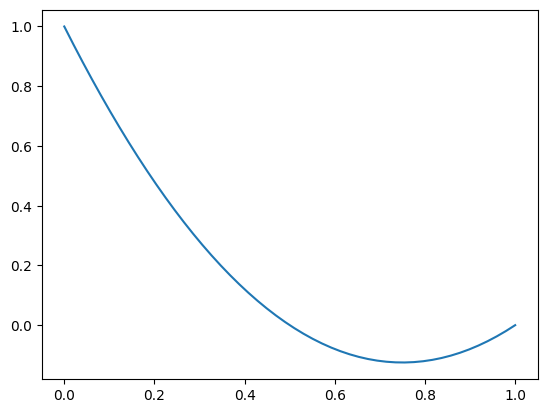

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def D(alpha):
    return 1 - 3*alpha +2*(alpha**2)

alphas = np.linspace(0, 1)

plt.plot(alphas, D(alphas))

In [16]:
def Ch(gamma, tau, alpha, theta_h):
    d = D(alpha)
    return gamma * tau * d - gamma * (1 - theta_h)

def Cl(gamma, tau, alpha, theta_h, theta_l):
    d = D(alpha)
    return gamma * (1 - theta_h) - (1-theta_l) + tau * (1 - gamma) * d

theta_h = 2 / 3
theta_l = 5 / 6
num_types = 10000
alphas = np.linspace(0, 0.5, num_types)
gamma = 0.9
tau = 1

In [24]:
np.concatenate((np.linspace(0.01, 0.49, 49), np.linspace(0.51, 0.65, 15)))

array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 , 0.11,
       0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21, 0.22,
       0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32, 0.33,
       0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43, 0.44,
       0.45, 0.46, 0.47, 0.48, 0.49, 0.51, 0.52, 0.53, 0.54, 0.55, 0.56,
       0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65])

In [21]:
np.linspace(0.51, 0.75, 25),

(array([0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61,
        0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72,
        0.73, 0.74, 0.75]),)

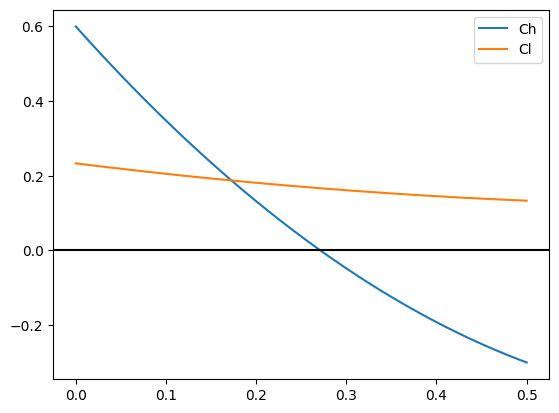

In [17]:
plt.plot(alphas, Ch(gamma, tau, alphas, theta_h), label="Ch")
plt.plot(alphas, Cl(gamma, tau, alphas, theta_h, theta_l), label="Cl")
plt.axhline(y=0, c="k")
plt.legend()
plt.show()

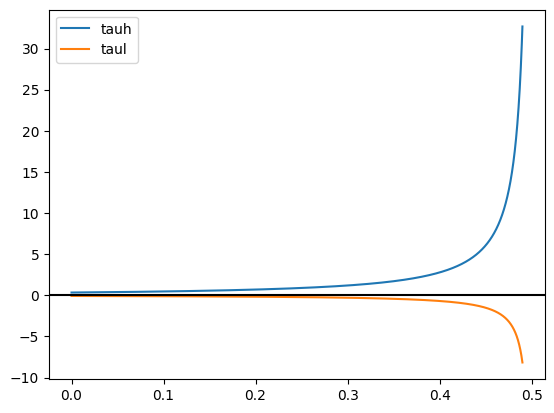

In [31]:
def tauh(gamma, tau, alpha, theta_h):
    d = D(alpha)
    return (1 - theta_h) / d

def taul(gamma, tau, alpha, theta_h, theta_l):
    d = D(alpha)
    return ((1 - theta_l) - gamma * (1 - theta_h)) / ((1 - gamma) * d)

theta_h = 2 / 3
theta_l = 5 / 6
num_types = 10000
alphas = np.linspace(0, 0.49, num_types)
gamma = 0.6

plt.plot(alphas, tauh(gamma, tau, alphas, theta_h), label="tauh")
plt.plot(alphas, taul(gamma, tau, alphas, theta_h, theta_l), label="taul")
plt.axhline(y=0, c="k")
#plt.ylim(top=1, bottom=-0.05)
plt.legend()
plt.show()

In [27]:
2/3

0.6666666666666666

In [422]:
from scipy.optimize import minimize 

def objective(vars):
    x_l, x_h, trans_h, trans_l = vars
    cost_h = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - x_h) - (1 - x_h) * (1 - 2 * prob_state0))
    cost_l = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - x_l) - (1 - x_l) * (1 - 2 * prob_state0))
    return -gamma * (trans_h - cost_h) - (1-gamma) * (trans_l - cost_l)

def constraint1(vars):
    x_l, x_h, trans_h, trans_l = vars
    return (1 - theta_h) * (x_h - x_l) - (trans_h - trans_l)


def constraint2(vars):
    x_l, x_h, trans_h, trans_l = vars
    return (1 - theta_l) * (x_l - x_h) - (trans_l - trans_h)


def constraint3(vars):
    x_l, x_h, trans_h, trans_l = vars
    return (1 - theta_l) * x_l - trans_l

def constraint4(vars):
    x_l, x_h, trans_h, trans_l = vars
    return (1 - theta_h) * x_h - trans_h

prob_state0s = np.linspace(0.501, 0.99)
prob_state0s = [0.8]
funs = []
transfers = []
costs = []
objectives = []
for prob_state0 in prob_state0s:

    prob_state0 = 0.8

    bounds = [(-1, 1), (-1, 1), (0, None), (0, None)]

    # Initial guess for the variables
    tau = 0.8
    #prob_state0 = 0.1209
    theta_h = 2/3
    theta_l = 5/6
 
    gamma = 0.4


    constraints = [
            {'type': 'ineq', 'fun': constraint1},
            {'type': 'ineq', 'fun': constraint2},
            {'type': 'ineq', 'fun': constraint3},
            {'type': 'ineq', 'fun': constraint4},
        ]
    x0 = [0, 0, 1, 1]
    result = minimize(
                objective,
                x0,
                method='SLSQP',
                bounds=bounds,
                constraints=constraints,
                tol=1e-10,
                options={"maxiter":10000000}
            )
    
    x_l, x_h, trans_h, trans_l  = result.x
    x_l, x_h, trans_h, trans_l
    
    expected_transfer = trans_h * gamma +  trans_l * (1-gamma)
    expected_transfer

    cost_h = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - x_h) - (1 - x_h) * (1 - 2 * prob_state0))
    cost_l = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - x_l) - (1 - x_l) * (1 - 2 * prob_state0))
    expected_cost = cost_h * gamma + cost_l * (1-gamma)
    expected_cost

    transfers.append(expected_transfer)
    costs.append(expected_cost)
    objectives.append(expected_transfer - expected_cost)
    print(x_l, x_h)

        
    
    funs.append(-result.fun)

1.0 1.0


In [435]:
type_low = theta_l
type_high = theta_h
prob_state0 = 0.8
phi = 0.54

def tau_critical_low(type_low: float, type_high: float, prob_state0: float, phi: float) -> float:
    return ((1 - type_low) - phi * (1 - type_high)) / ((1 - phi) * D(prob_state0))


def tau_critical_high(type_high: float, prob_state0: float) -> float:
    return (1 - type_high) / D(prob_state0)

tau_critical_low(type_low, type_high, prob_state0, phi), tau_critical_high(type_high, prob_state0)

(0.24154589371980761, -2.7777777777777755)

In [433]:
transfers1 = transfers
costs1 = costs
objectives1 = objectives

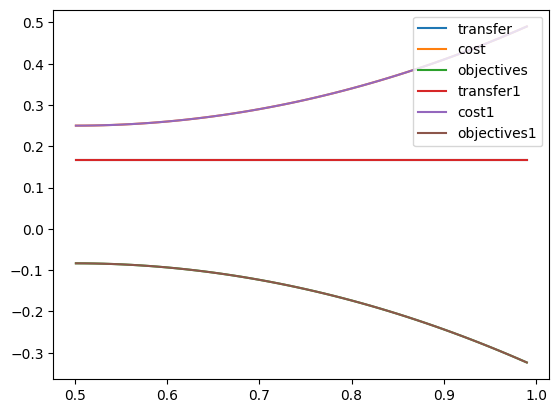

In [ ]:
plt.plot(prob_state0s, transfers, label="transfer")
plt.plot(prob_state0s, costs, label="cost")
plt.plot(prob_state0s, objectives, label="objectives")

plt.plot(prob_state0s, transfers1, label="transfer1")
plt.plot(prob_state0s, costs1, label="cost1")
plt.plot(prob_state0s, objectives1, label="objectives1")
plt.legend()

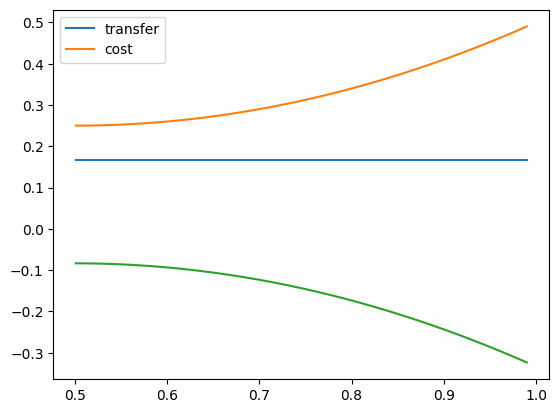

In [383]:
plt.plot(prob_state0s, transfers, label="transfer")
plt.plot(prob_state0s, costs, label="cost")
plt.plot(prob_state0s, objectives)
plt.legend()

In [375]:
transfers, costs, objectives, x_l

([np.float64(0.16333333333333633)],
 [np.float64(0.238475)],
 [np.float64(-0.07514166666666366)],
 np.float64(0.0))

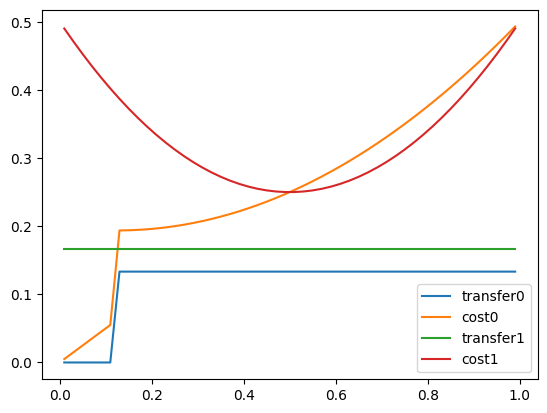

In [367]:
plt.plot(prob_state0s, transfers_bound0, label="transfer0")
plt.plot(prob_state0s, costs_bound0, label="cost0")
plt.legend()

plt.plot(prob_state0s, transfers, label="transfer1")
plt.plot(prob_state0s, costs, label="cost1")
plt.legend()

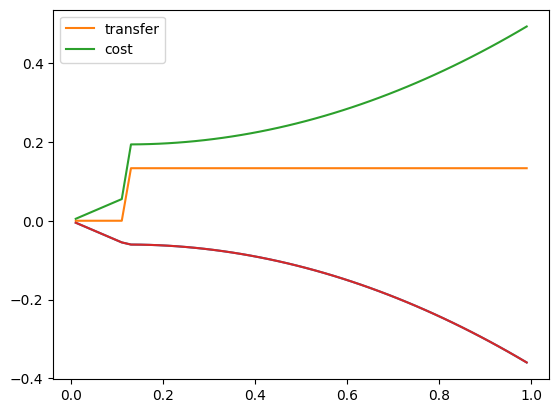

In [ ]:
plt.plot(prob_state0s, transfers, label="transfer")
plt.plot(prob_state0s, costs, label="cost")
plt.legend()

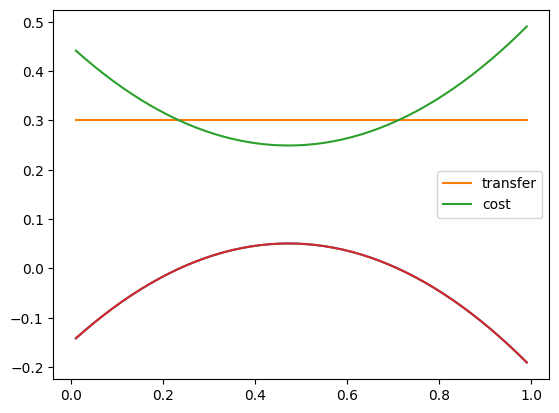

In [326]:
plt.plot(prob_state0s, funs)
plt.plot(prob_state0s, transfers, label="transfer")
plt.plot(prob_state0s, costs, label="cost")
plt.plot(prob_state0s, objectives)
plt.legend()

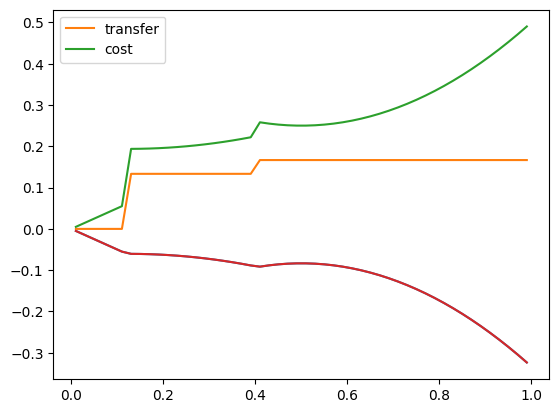

In [316]:
plt.plot(prob_state0s, funs)
plt.plot(prob_state0s, transfers, label="transfer")
plt.plot(prob_state0s, costs, label="cost")
plt.plot(prob_state0s, objectives)
plt.legend()

In [265]:
result.fun

np.float64(0.06042339066666476)

In [262]:
expected_transfer = trans_h * gamma +  trans_l * gamma
expected_transfer

np.float64(0.13333333333333328)

In [259]:
cost_h = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - x_h) - (1 - x_h) * (1 - 2 * prob_state0))
cost_l = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - x_l) - (1 - x_l) * (1 - 2 * prob_state0))
expected_cost = cost_h * gamma +  cost_l * gamma
expected_cost

np.float64(0.0481999999999998)

In [263]:
cost_h = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - x_h) - (1 - x_h) * (1 - 2 * prob_state0))
cost_l = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - x_l) - (1 - x_l) * (1 - 2 * prob_state0))
expected_cost = cost_h * gamma +  cost_l * gamma
expected_cost

np.float64(0.18166672399999842)

In [264]:
expected_transfer - expected_cost

np.float64(-0.048333390666665144)

In [236]:
def calculate_exerpiment_value2(informativeness: float, type: float) -> float:
    return np.maximum(
        -10,
        type * informativeness
        + 1
        + np.minimum(-informativeness, 0)
        - (1 - type) * (type <= 0.5)
        - type * (type > 0.5),
    )

(0.0, 0.4257575757575758)

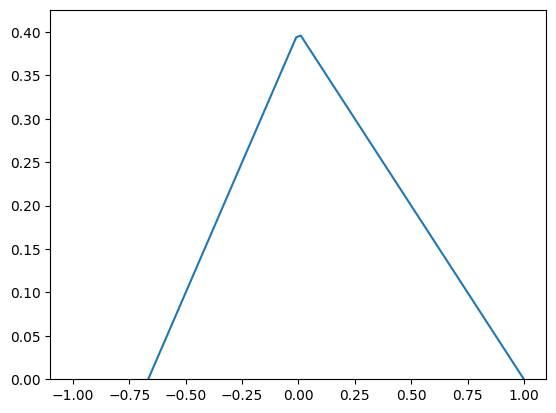

In [439]:
informativeness = np.linspace(-1, 1, 100)
prob_state0 = 0.6

plt.plot(informativeness, calculate_exerpiment_value2(informativeness, prob_state0))
plt.ylim(bottom=0)

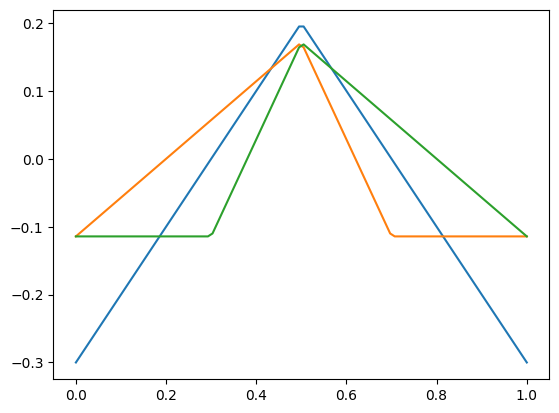

In [471]:
a = 4/7

informativeness = a - 1
prob_state0s = np.linspace(0, 1, 100)

theta_h = 7/10
theta_l = 1/5

def calculate_exerpiment_value2(informativeness: float, type: float, payment) -> float:
    return np.maximum(
        0,
        type * informativeness
        + 1
        + np.minimum(-informativeness, 0)
        - (1 - type) * (type <= 0.5)
        - type * (type > 0.5),
    ) -  payment

plt.plot(prob_state0s, calculate_exerpiment_value2(0, prob_state0s, 1-theta_h))
plt.plot(prob_state0s, calculate_exerpiment_value2(informativeness, prob_state0s, theta_l * a))
plt.plot(prob_state0s, calculate_exerpiment_value2(-informativeness, prob_state0s, theta_l * a))

#plt.ylim(bottom=0)

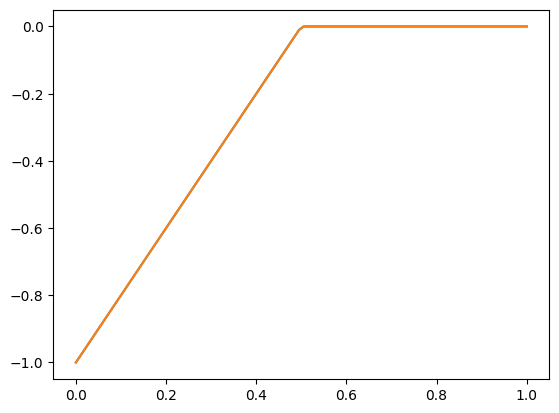

In [513]:
a = (2 * theta_h - 1) / (theta_h - theta_l)
theta_l = 0.1
theta_h = 0.7
a = (2 * theta_h - 1) / (theta_h - theta_l)

informativeness = a - 1
prob_state0s = np.linspace(0, 1, 100)



def calculate_exerpiment_value2(informativeness: float, type: float, payment) -> float:
    return np.maximum(
        0,
        type * informativeness
        + 1
        + np.minimum(-informativeness, 0)
        - (1 - type) * (type <= 0.5)
        - type * (type > 0.5),
    ) -  payment

for theta_h in [0.7, 0.8]:
    plt.plot(prob_state0s, calculate_exerpiment_value2(0, prob_state0s, 1-prob_state0s))
# plt.plot(prob_state0s, calculate_exerpiment_value2(informativeness, prob_state0s, theta_l * a))
# plt.plot(prob_state0s, calculate_exerpiment_value2(-informativeness, prob_state0s, theta_l * a))

#plt.ylim(bottom=0)

In [176]:
def actions(
    informativeness: float, types: np.ndarray[float], sample_size: int, p
):
    actions = []
    for i in range(100):
        state = np.random.choice([0, 1], p=[p, 1-p])
        
        prob_signal0_state0 = 1 if informativeness > 0 else 1 + informativeness
        prob_signal1_state1 = 1 if informativeness <= 0 else 1 - informativeness

        prob_signal0_state1 = 1 - prob_signal1_state1
        prob_signal1_state0 = 1 - prob_signal0_state0

        prob_signal0 = prob_signal0_state0 * types + prob_signal0_state1 * (1 - types)
        prob_signal1 = prob_signal1_state0 * types + prob_signal1_state1 * (1 - types)

        prob_state0_signal0 = prob_signal0_state0 * types / prob_signal0
        prob_state0_signal1 = prob_signal1_state0 * types / prob_signal1

        signals = np.random.uniform(0, 1, size=sample_size) <= (
            prob_signal1_state1 if state == 1 else prob_signal1_state0
        )

        probs_state0 = signals * prob_state0_signal1 + (1 - signals) * prob_state0_signal0

        action = (probs_state0 < 0.5).mean(axis=0)
        actions.append(action)
   
    return int(np.mean(actions) >= 0.5)

In [463]:
4/7 - 1

-0.4285714285714286

In [440]:
informativeness = 0.999

prob_action1s = []
iss = np.linspace(-0.99, 0.99, 50)
for informativeness in iss:
    prob_state0 = 0.9
    states = np.random.choice([0, 1], p=[prob_state0, 1-prob_state0], size=10000)
    prob_signal0_state0 = 1 if informativeness > 0 else 1 + informativeness
    prob_signal1_state1 = 1 if informativeness <= 0 else 1 - informativeness

    prob_signal0_state1 = 1 - prob_signal1_state1
    prob_signal1_state0 = 1 - prob_signal0_state0

    prob_action0 = np.mean((states * prob_signal0_state1 + (1-states) * prob_signal0_state0))
    prob_action0, 1-prob_action0
    prob_action1s.append(1-prob_action0)

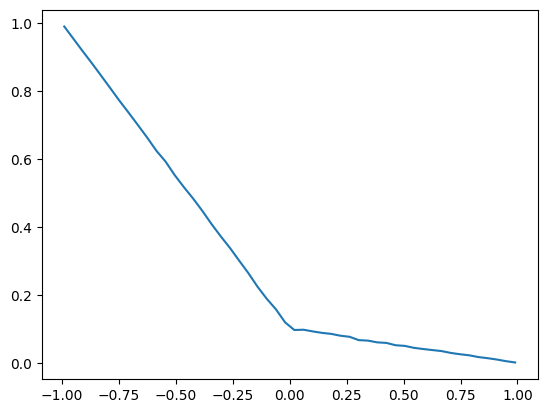

In [441]:
plt.plot(iss, prob_action1s)

(0.0, 0.4727272727272726)

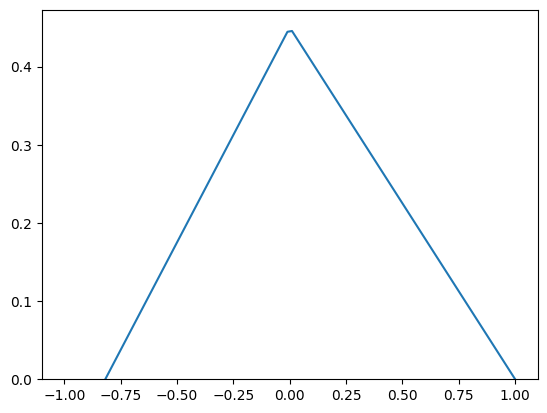

In [ ]:
informativeness = np.linspace(-1, 1, 100)
t = 0.5

plt.plot(informativeness, calculate_exerpiment_value2(informativeness, t))
plt.ylim(bottom=0)

In [191]:
prob_signal0_state1

0.5

In [180]:
prob_state0s = np.linspace(0.01, 0.99)

allocation = -0.7
prob_state0 = 0.1
type = 0.7
allocations = np.linspace(-0.99, 0.99, 21)
for allocation in allocations:
    print(allocation, actions(allocation, type, 10000, p=prob_state0))

-0.99 0
-0.891 0
-0.792 0
-0.693 0
-0.594 0
-0.495 0
-0.3959999999999999 1
-0.29699999999999993 1
-0.19799999999999995 1
-0.09899999999999998 1
0.0 1
0.09899999999999998 1
0.19800000000000018 1
0.29700000000000015 1
0.39600000000000013 1
0.4950000000000001 0
0.5940000000000001 0
0.6930000000000001 0
0.792 0
0.891 0
0.99 0


In [178]:
prob_state0s = np.linspace(0.01, 0.99)

allocation = 0.999

plt.plot(prob_state0s, actions(allocation, prob_state0s, 100000, p=prob_state0))

ValueError: operands could not be broadcast together with shapes (100000,) (50,) 

In [443]:
theta_h = 7/10
theta_l = 1/5

-1 / (theta_h - theta_l)

-2.0000000000000004

In [447]:
(2 * theta_h - 1) / (theta_h - theta_l) - 1

-0.20000000000000007

In [685]:
def objective(vars):
    pi1_l, pi2_h, trans_l, trans_h = vars
    cost_h = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - pi2_h) - (1 - 2 * prob_state0) * (1 - pi2_h))
    cost_l = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (pi1_l - 1))
    return -gamma * (trans_h - cost_h) - (1-gamma) * (trans_l - cost_l)

def ic_l(vars):
    pi1_l, pi2_h, trans_l, trans_h = vars
    return theta_l * (pi1_l + pi2_h - 2) + 1 - pi2_h - trans_l + trans_h


def ic_h(vars):
    pi1_l, pi2_h, trans_l, trans_h = vars
    return theta_h * (2 - pi1_l - pi2_h) - 1 + pi2_h - trans_h + trans_l


def ir_l(vars):
    pi1_l, pi2_h, trans_l, trans_h = vars
    return theta_l * pi1_l - trans_l

def ir_h(vars):
    pi1_l, pi2_h, trans_l, trans_h = vars
    return (1 - theta_h) * pi2_h - trans_h

bounds = [(0, 1), (0, 1), (0, None), (0, None)]



# Initial guess for the variables
tau = 0.4
prob_state0 = 0.8
theta_h = 0.55
theta_l = 0.1
gamma = 0.1

pi1_ls = []
pi2_hs = []
trans_ls = []
trans_hs = []
taus = np.linspace(0, 1, 1000)
cost_ls = []
cost_hs = []

pi1_ls_bound1 = []
pi2_hs_bound1 = []
trans_ls_bound1 = []
trans_hs_bound1 = []
cost_ls_bound1 = []
cost_hs_bound1 = []

objectives = []
objectives_bound1 = []

pi1_ls_bound0 = []
pi2_hs_bound0 = []
trans_ls_bound0 = []
trans_hs_bound0 = []
cost_ls_bound0 = []
cost_hs_bound0 = []

lower_bound = (2 * theta_h - 1) / (theta_h - theta_l) 
objectives_bound0 = []

for tau in taus:

    bounds = [(0, 1), (0, 1), (0, None), (0, None)]

    constraints = [
        {'type': 'ineq', 'fun': ic_l},
        {'type': 'ineq', 'fun': ic_h},
        {'type': 'eq', 'fun': ir_l},
        {'type': 'eq', 'fun': ir_h},
    ]
    x0 = [1, 1, 1, 1]


    result = minimize(
                objective,
                x0,
                method='SLSQP',
                bounds=bounds,
                constraints=constraints,
                tol=1e-10,
                options={"maxiter":10000000}
            )

    
    pi1_l, pi2_h, trans_l, trans_h = result.x
    pi1_ls.append(pi1_l)
    pi2_hs.append(pi2_h)
    trans_ls.append(trans_l)
    trans_hs.append(trans_h)
    cost_h = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - pi2_h) - (1 - 2 * prob_state0) * (1 - pi2_h))
    cost_l = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (pi1_l - 1))
    cost_hs.append(cost_h)
    cost_ls.append(cost_l)
    #objectives.append(-result.fun)
    objectives.append(trans_l - cost_l)

    bounds = [(lower_bound-1e-3, lower_bound+1e-3), (0, 1), (0, None), (0, None)]

    constraints = [
        {'type': 'ineq', 'fun': ic_l},
        {'type': 'ineq', 'fun': ic_h},
        {'type': 'eq', 'fun': ir_l},
        {'type': 'eq', 'fun': ir_h},
    ]
    x0 = [1, 1, 1, 1]


    result = minimize(
                objective,
                x0,
                method='SLSQP',
                bounds=bounds,
                constraints=constraints,
                tol=1e-10,
                options={"maxiter":10000000}
            )

    
    pi1_l, pi2_h, trans_l, trans_h = result.x
    pi1_ls_bound1.append(pi1_l)
    pi2_hs_bound1.append(pi2_h)
    trans_ls_bound1.append(trans_l)
    trans_hs_bound1.append(trans_h)
    cost_h = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - pi2_h) - (1 - 2 * prob_state0) * (1 - pi2_h))
    cost_l = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (pi1_l - 1))
    cost_hs_bound1.append(cost_h)
    cost_ls_bound1.append(cost_l)
    #objectives_bound1.append(-result.fun)

    objectives_bound1.append(trans_l - cost_l)


    bounds = [(0, 0), (0, 1), (0, None), (0, None)]

    constraints = [
        {'type': 'ineq', 'fun': ic_l},
        {'type': 'ineq', 'fun': ic_h},
        {'type': 'eq', 'fun': ir_l},
        {'type': 'eq', 'fun': ir_h},
    ]
    x0 = [1, 1, 1, 1]


    result = minimize(
                objective,
                x0,
                method='SLSQP',
                bounds=bounds,
                constraints=constraints,
                tol=1e-10,
                options={"maxiter":10000000}
            )

    
    pi1_l, pi2_h, trans_l, trans_h = result.x

    cost_h = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - pi2_h) - (1 - 2 * prob_state0) * (1 - pi2_h))
    cost_l = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (pi1_l - 1))
   
    objectives_bound0.append(trans_l - cost_l)

    pi1_ls_bound0.append(pi1_l)
    pi2_hs_bound0.append(pi2_h)
    trans_ls_bound0.append(trans_l)
    trans_hs_bound0.append(trans_h)
    cost_h = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - pi2_h) - (1 - 2 * prob_state0) * (1 - pi2_h))
    cost_l = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (pi1_l - 1))
    cost_hs_bound0.append(cost_h)
    cost_ls_bound0.append(cost_l)



-0.7777777777777777


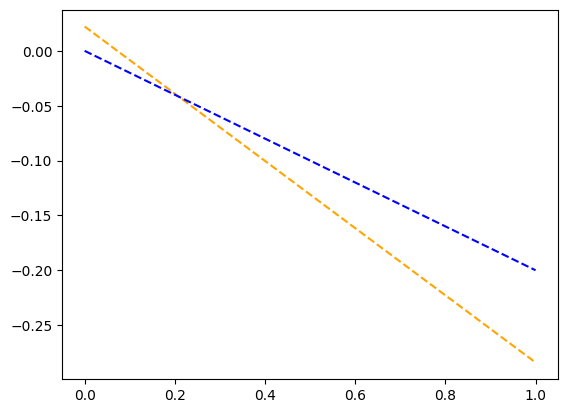

In [692]:
lower_bound = (2 * theta_h - 1) / (theta_h - theta_l) - 1
print(lower_bound)

# plt.plot(taus, trans_ls, color="blue")
# plt.plot(taus, trans_ls_bound1, color="blue", ls="dashed")

# plt.plot(taus, cost_ls, color="red")
# plt.plot(taus, cost_ls_bound1, color="red", ls="dashed")

plt.plot(taus, objectives_bound1, color="orange", ls="dashed")
plt.plot(taus, objectives_bound0, color="blue", ls="dashed")

-0.7777777777777777


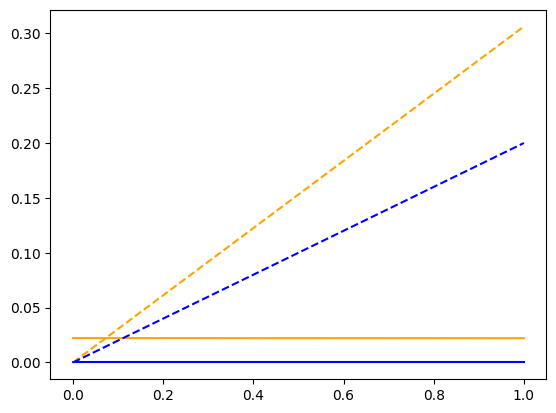

In [696]:
lower_bound = (2 * theta_h - 1) / (theta_h - theta_l) - 1
print(lower_bound)

plt.plot(taus, trans_ls_bound1, color="orange", ls="solid")
plt.plot(taus, trans_ls_bound0, color="blue", ls="solid")

plt.plot(taus, cost_ls_bound1, color="orange", ls="dashed")
plt.plot(taus, cost_ls_bound0, color="blue", ls="dashed")


-0.7777777777777777


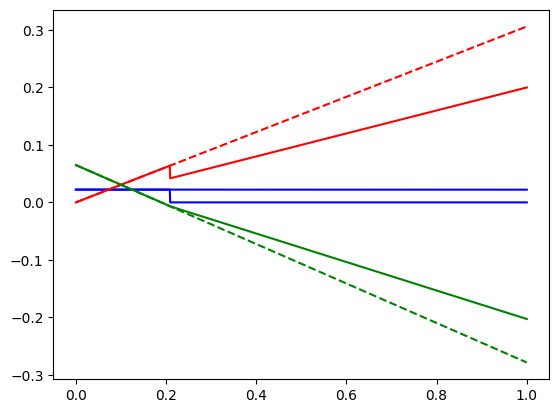

In [672]:
# increased precision, theta_h closer to1 further from 0.5
lower_bound = (2 * theta_h - 1) / (theta_h - theta_l) - 1
print(lower_bound)

plt.plot(taus, trans_ls, color="blue")
plt.plot(taus, trans_ls_bound1, color="blue")

plt.plot(taus, cost_ls, color="red")
plt.plot(taus, cost_ls_bound1, color="red", ls="dashed")

plt.plot(taus, objectives, color="green")
plt.plot(taus, objectives_bound1, color="green", ls="dashed")

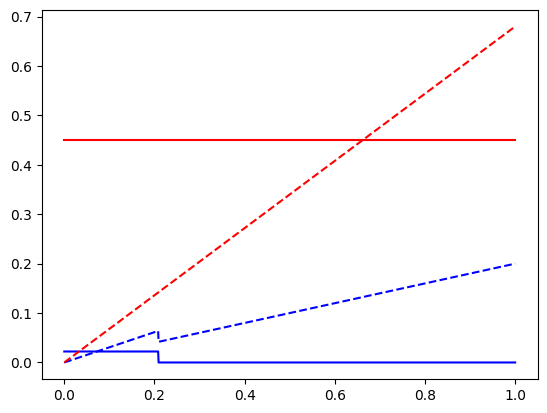

In [674]:
plt.plot(taus, trans_ls, color="blue")
plt.plot(taus, trans_hs, color="red")
plt.plot(taus, cost_ls, color="blue", ls="dashed")
plt.plot(taus, cost_hs, color="red", ls="dashed")

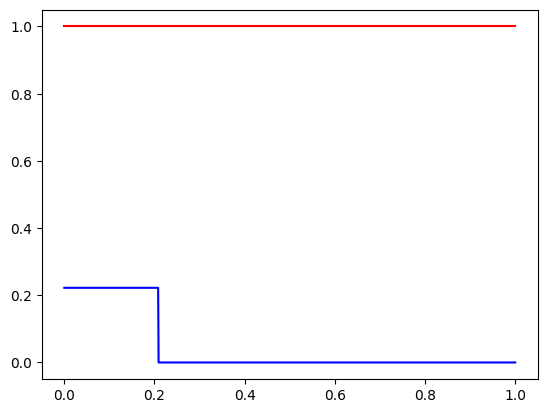

In [675]:
plt.plot(taus, pi1_ls, color="blue")
plt.plot(taus, pi2_hs, color="red")